In [1]:
# Write a program in python to demonstrate Handwritten Digit Recognition on MNIST dataset.

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [4]:
(train_images,train_labels),(test_images,test_labels)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [5]:
train_images,test_images=train_images/255.0,test_images/255.0
train_labels,test_labels=to_categorical(train_labels),to_categorical(test_labels)

In [8]:
model=tf.keras.Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

C:\Users\lapto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.fit(train_images,train_labels,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9135 - loss: 0.3002
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9565 - loss: 0.1461
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9677 - loss: 0.1077
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9721 - loss: 0.0892
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9755 - loss: 0.0784


In [10]:
loss,acc=model.evaluate(test_images,test_labels)
print(loss,acc)
pred=model.predict(test_images)
pred_labels=tf.argmax(pred,axis=1)
true_labels=tf.argmax(test_labels,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.9790 - loss: 0.0699
0.06985431164503098 0.9789999723434448
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step


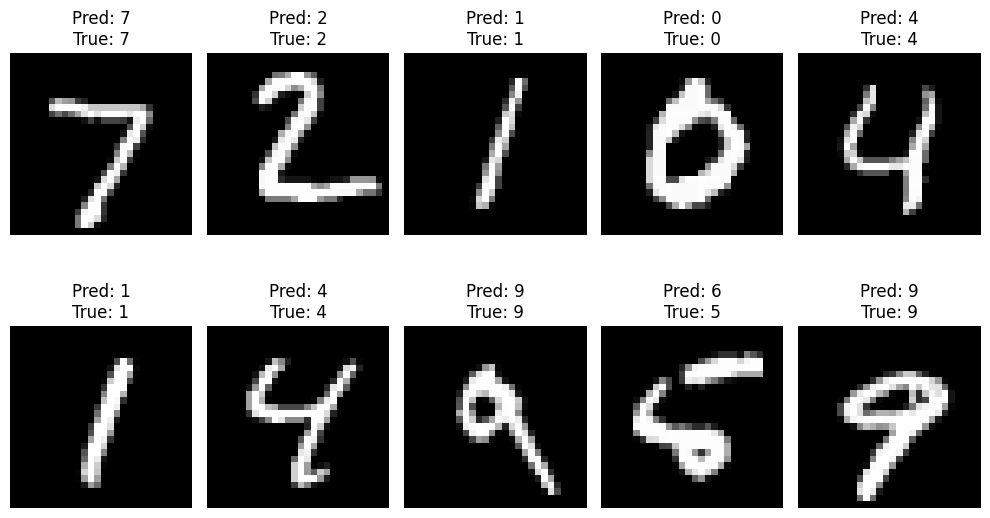

In [12]:
plt.figure(figsize=(10,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(test_images[i],cmap='gray')
    plt.title(f"Pred: {pred_labels[i]}\nTrue: {true_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()